In [1]:
%pip install mediapipe numpy matplotlib opencv-python

Note: you may need to restart the kernel to use updated packages.


### Naruto Hand Gesture Recognition MediaPipe HandLandmarker + PyTorch MLP

In [2]:
DATA_DIR       = "./dataset"        
FEATURES_PATH  = "features.npz"
MODEL_PATH_OUT = "model.pt"
TEST_IMAGE     = "test.jpg"        
EPOCHS         = 100
LR             = 1e-3
BATCH_SIZE     = 32
MAX_HANDS      = 2             


In [3]:
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision


%matplotlib inline

## 1. HandLandmarker setup

In [19]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
LANDMARKER_MODEL_PATH = "hand_landmarker.task"

def ensure_model():
    if not os.path.exists(LANDMARKER_MODEL_PATH):
        print("Downloading hand_landmarker.task ...")
        urllib.request.urlretrieve(MODEL_URL, LANDMARKER_MODEL_PATH)
    return LANDMARKER_MODEL_PATH

def make_landmarker(detection_confidence=0.3):
    # lower confidence than the live-tracking default (0.5) — during dataset
    # extraction we want max recall on stored images, not conservative live filtering
    base_options = mp_python.BaseOptions(model_asset_path=ensure_model())
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.IMAGE,
        num_hands=MAX_HANDS,
        min_hand_detection_confidence=detection_confidence,
        min_hand_presence_confidence=detection_confidence,
        min_tracking_confidence=detection_confidence,
    )
    return vision.HandLandmarker.create_from_options(options)

def single_hand_vec(hand_landmarks):
    coords = np.array([[p.x, p.y, p.z] for p in hand_landmarks], dtype=np.float32)  # (21,3)
    coords -= coords[0]  # wrist-relative
    scale = np.max(np.linalg.norm(coords, axis=1))
    if scale > 1e-6:
        coords /= scale
    return coords.flatten()

def landmarks_to_vec(result):
    """
    Builds a FIXED-SIZE, FIXED-ORDER feature vector regardless of detection order.
    MAX_HANDS=1 -> 63-d (single hand, zero vec if nothing detected — caller should skip that case).
    MAX_HANDS=2 -> 130-d = [Left 63-d, Right 63-d, inter-hand 4-d], zero-padded if a hand is missing.
    Ordering by handedness (not detection order) matters: without it, hand A's landmarks
    could land in slot 0 for one sample and slot 1 for another, teaching the network noise.

    The inter-hand 4-d block (dx, dy, dz, distance) fixes a real gap: single_hand_vec
    normalizes each hand independently (own wrist, own scale), so on its own the model
    has NO information about how far apart the two hands are — e.g. the "dog" sign
    (fist + flat hand stacked close) vs. the same two shapes held far apart would look
    identical without this. The delta is computed on raw wrist positions BEFORE each
    hand gets rescaled, then divided by the average of both hands' own scale so it stays
    invariant to camera distance while still encoding relative separation.
    """
    if MAX_HANDS == 1:
        if not result.hand_landmarks:
            return None
        return single_hand_vec(result.hand_landmarks[0])

    slots = {"Left": np.zeros(63, dtype=np.float32), "Right": np.zeros(63, dtype=np.float32)}
    wrist, scale = {}, {}

    for hand_landmarks, handedness in zip(result.hand_landmarks, result.handedness):
        label = handedness[0].category_name
        coords = np.array([[p.x, p.y, p.z] for p in hand_landmarks], dtype=np.float32)
        w = coords[0].copy()
        rel = coords - w
        s = np.max(np.linalg.norm(rel, axis=1))
        if s > 1e-6:
            rel = rel / s
        slots[label] = rel.flatten()
        wrist[label], scale[label] = w, (s if s > 1e-6 else 1.0)

    if "Left" in wrist and "Right" in wrist:
        avg_scale = (scale["Left"] + scale["Right"]) / 2.0
        delta = (wrist["Right"] - wrist["Left"]) / avg_scale
        inter = np.concatenate([delta, [np.linalg.norm(delta)]]).astype(np.float32)  # 4-d
    else:
        inter = np.zeros(4, dtype=np.float32)  # one hand missing -> no inter-hand info

    return np.concatenate([slots["Left"], slots["Right"], inter])  # 130-d

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]


## 2. Extract landmarks from the dataset
- Extract features from all images and store in a .npz format 
- skipping all images where hands aren't detected
- in the current dataset a good chunk is being skipped 
- Approximately ~ 1000 are dropped out of 1800 ish images

In [20]:
# drop images where hands aren't detected (because they'll only return null)
# store in a features.npz format (which is just a format for storing large arrays)

def extract_landmarks(data_dir, out_path):
    landmarker = make_landmarker()  # uses the lower detection_confidence default now

    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    X, y = [], []
    per_class_counts = {c: 0 for c in classes}
    skipped = 0
    skipped_files = []  # inspect these after the run to see if drops are real quality issues

    for c in classes:
        folder = os.path.join(data_dir, c)
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = os.path.join(folder, fname)
            img = cv2.imread(path)
            if img is None:
                skipped += 1
                skipped_files.append((path, "unreadable"))
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            import mediapipe as mp
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result = landmarker.detect(mp_image)

            if not result.hand_landmarks:
                skipped += 1
                skipped_files.append((path, "no_hand_detected"))
                continue

            vec = landmarks_to_vec(result)
            if vec is None:
                skipped += 1
                skipped_files.append((path, "vec_none"))
                continue

            X.append(vec)
            y.append(class_to_idx[c])
            per_class_counts[c] += 1

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    print(f"Extracted {len(X)} samples, skipped {skipped} (no hand detected / unreadable)")
    np.savez(out_path, X=X, y=y, classes=np.array(classes))
    landmarker.close()
    return X, y, classes, per_class_counts, skipped_files

X, y, classes, per_class_counts, skipped_files = extract_landmarks(DATA_DIR, FEATURES_PATH)


Extracted 2226 samples, skipped 668 (no hand detected / unreadable)


668 files skipped total


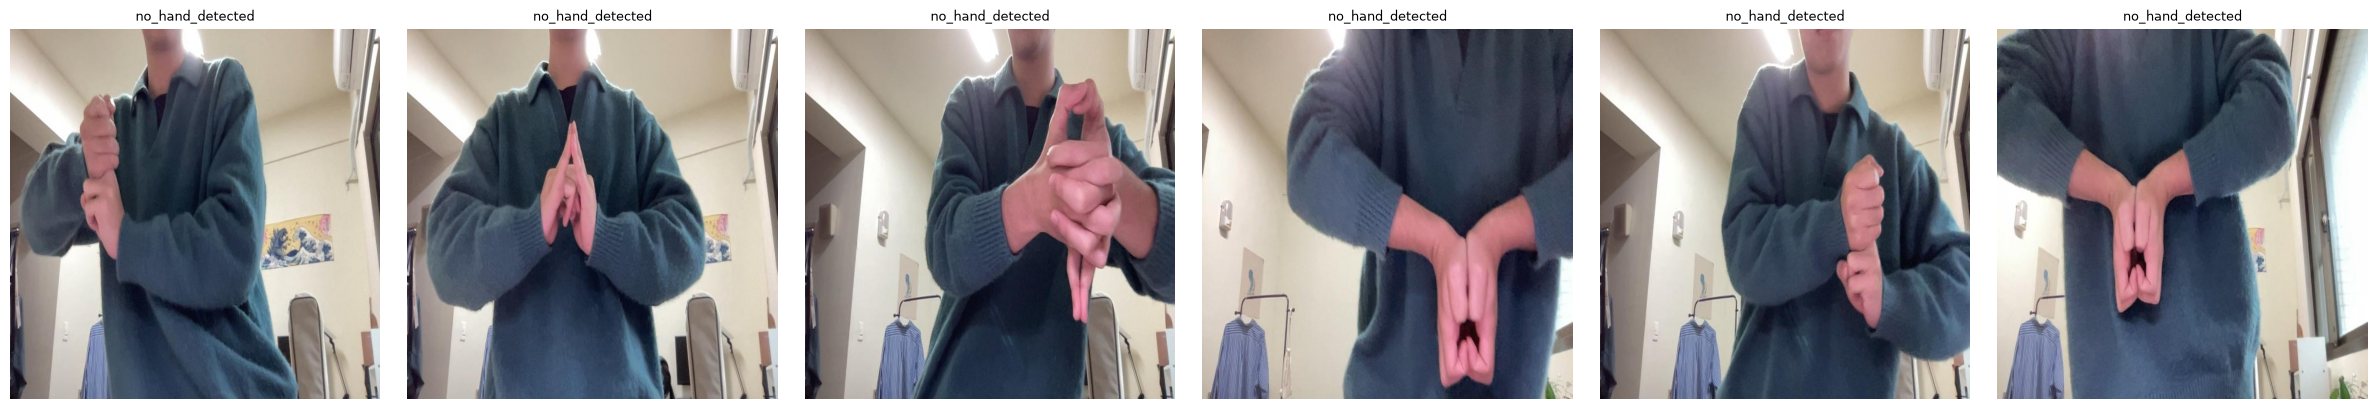

In [21]:
# quick sanity check on what's actually getting dropped — pull a few and eyeball them
import random

print(f"{len(skipped_files)} files skipped total")
sample = random.sample(skipped_files, min(6, len(skipped_files)))
fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
if len(sample) == 1:
    axes = [axes]
for ax, (path, reason) in zip(axes, sample):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB) if os.path.exists(path) else None
    if img is not None:
        ax.imshow(img)
    ax.set_title(reason, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Class distribution
how many usable samples landed in each class after landmark detection.

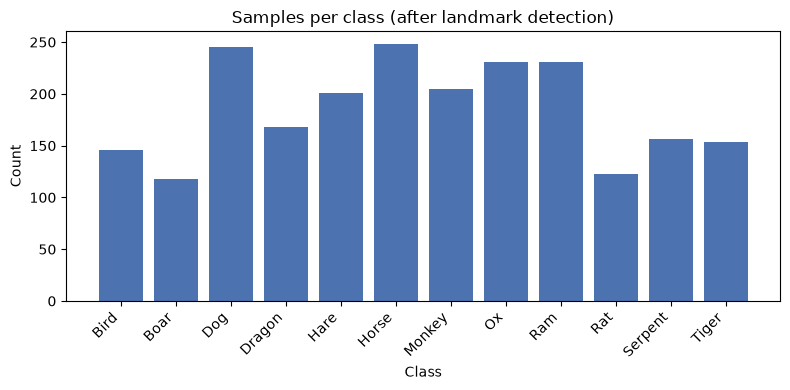

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(per_class_counts.keys(), per_class_counts.values(), color="#4C72B0")
plt.title("Samples per class (after landmark detection)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Sample hand skeletons

One normalized landmark plot per class, to visually confirm the detections look sane.

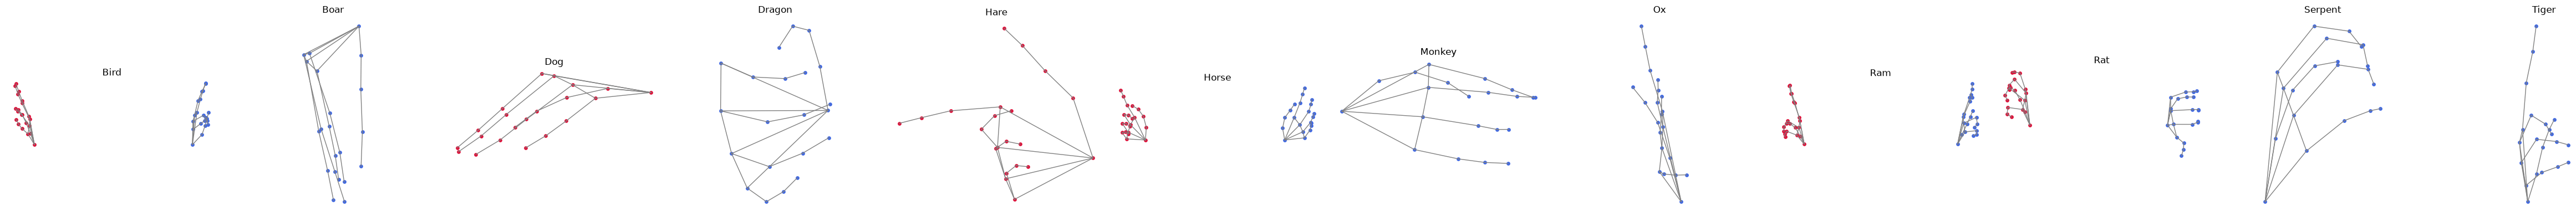

In [23]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))

if len(classes) == 1:
    axes = [axes]

def plot_hand(ax, coords, color, x_offset=0.0):
    if not np.any(coords):  # all-zero = padded/missing hand, skip drawing
        return
    for a, b in HAND_CONNECTIONS:
        ax.plot([coords[a, 0] + x_offset, coords[b, 0] + x_offset],
                [-coords[a, 1], -coords[b, 1]], "gray", linewidth=1)
    ax.scatter(coords[:, 0] + x_offset, -coords[:, 1], c=color, s=15)

for ax, c in zip(axes, classes):
    idx = np.where(y == classes.index(c))[0]
    if len(idx) == 0:
        ax.set_title(f"{c} (no samples)")
        continue
    sample = X[idx[0]]
    if MAX_HANDS == 1:
        plot_hand(ax, sample.reshape(21, 3), "crimson")
    else:
        # first 126 dims are landmarks (63 left + 63 right); trailing 4 are the
        # inter-hand delta (dx, dy, dz, dist) — not landmark coords, skip them here
        left, right = sample[:63].reshape(21, 3), sample[63:126].reshape(21, 3)
        plot_hand(ax, left, "crimson", x_offset=-1.2)
        plot_hand(ax, right, "royalblue", x_offset=1.2)
    ax.set_title(c)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Model

In [24]:
def build_model(input_dim, num_classes):
    return nn.Sequential(
        nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, num_classes)
    )

## 4. Train

Tracks train loss, val loss, and val accuracy per epoch for plotting afterward.

In [25]:
dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
n_val = max(1, int(0.15 * len(dataset)))
train_ds, val_ds = random_split(dataset, [len(dataset) - n_val, n_val])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_model(X.shape[1], len(classes)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_ds)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += crit(out, yb).item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    val_loss /= len(val_ds)
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"state_dict": model.state_dict(),
                    "classes": classes,
                    "input_dim": X.shape[1]}, MODEL_PATH_OUT)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")

print(f"Best val_acc: {best_acc:.4f} | saved to {MODEL_PATH_OUT}")

epoch   0 | train_loss 2.1196 | val_loss 1.5949 | val_acc 0.5225
epoch  10 | train_loss 0.5423 | val_loss 0.4170 | val_acc 0.8799
epoch  20 | train_loss 0.2945 | val_loss 0.1754 | val_acc 0.9610
epoch  30 | train_loss 0.1784 | val_loss 0.1159 | val_acc 0.9730
epoch  40 | train_loss 0.1407 | val_loss 0.0871 | val_acc 0.9790
epoch  50 | train_loss 0.1125 | val_loss 0.0753 | val_acc 0.9760
epoch  60 | train_loss 0.0910 | val_loss 0.0675 | val_acc 0.9820
epoch  70 | train_loss 0.0741 | val_loss 0.0479 | val_acc 0.9880
epoch  80 | train_loss 0.0554 | val_loss 0.0575 | val_acc 0.9910
epoch  90 | train_loss 0.0653 | val_loss 0.0518 | val_acc 0.9850
epoch  99 | train_loss 0.0432 | val_loss 0.0507 | val_acc 0.9880
Best val_acc: 0.9910 | saved to model.pt


### Loss curves

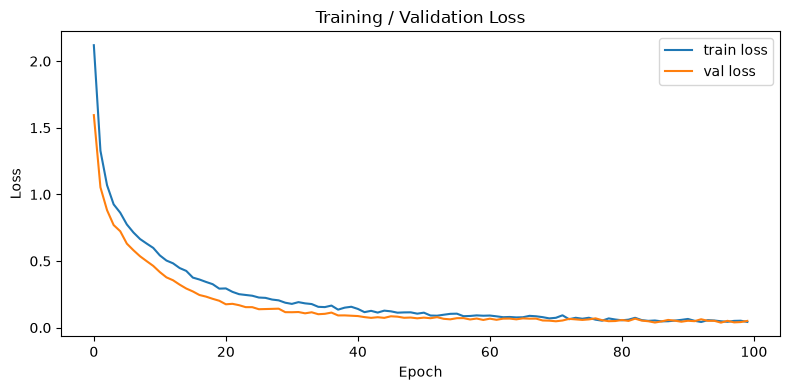

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Validation accuracy curve

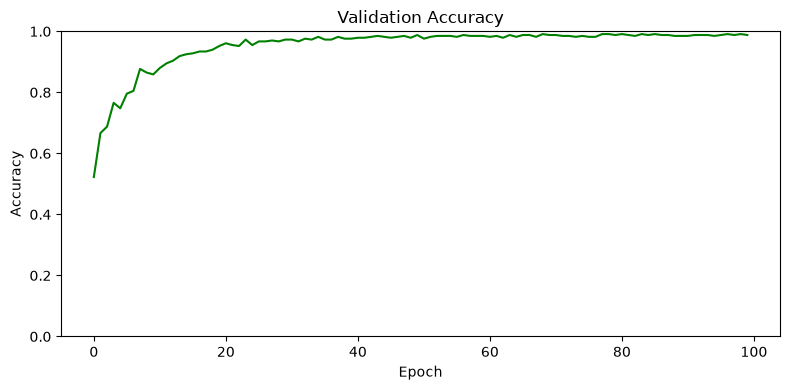

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(history["val_acc"], color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Confusion matrix

Loads the best checkpoint and evaluates on the validation split.

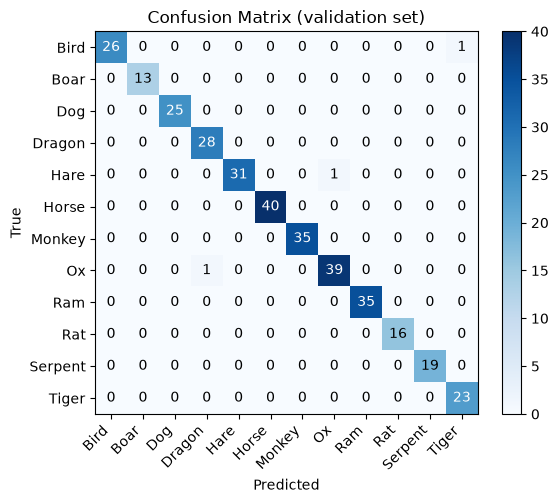

In [28]:
from sklearn.metrics import confusion_matrix

ckpt = torch.load(MODEL_PATH_OUT, map_location=device)
best_model = build_model(ckpt["input_dim"], len(classes)).to(device)
best_model.load_state_dict(ckpt["state_dict"])
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        pred = best_model(xb).argmax(1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (validation set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

### Per-class accuracy

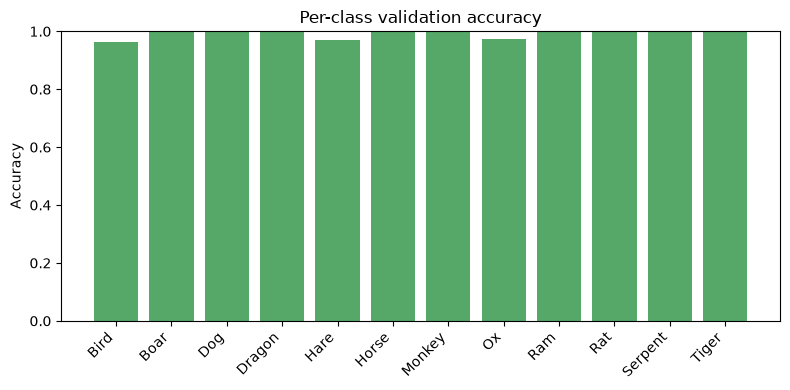

In [29]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)

plt.figure(figsize=(8, 4))
plt.bar(classes, per_class_acc, color="#55A868")
plt.title("Per-class validation accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Inference on a testing images


In [ ]:
NONE_THRESHOLD = 0.6  # tune against your val set; predictions below this become "none"

def infer_dataset(model_path, root_dir, cols=4, figsize_per_img=3.2, per_class=2,
                   none_threshold=NONE_THRESHOLD):
    """
    Runs inference on up to `per_class` images per subdirectory under root_dir
    and displays them all in a labeled grid: true label vs predicted label.
    Predictions with confidence below `none_threshold` are reported as "none"
    instead of the raw argmax class — this is what actually protects you from
    confidently misclassifying garbage/off-distribution gestures.
    """
    import math
    import mediapipe as mp

    # load model + landmarker ONCE, not per image
    ckpt = torch.load(model_path, map_location="cpu")
    classes_ = ckpt["classes"]
    m = build_model(ckpt["input_dim"], len(classes_))
    m.load_state_dict(ckpt["state_dict"])
    m.eval()

    landmarker = make_landmarker()

    subdirs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    results = []  # each: dict(img_rgb, hand_landmarks, true_label, pred_label, conf, status)

    for true_label in subdirs:
        folder = os.path.join(root_dir, true_label)
        image_files = [f for f in sorted(os.listdir(folder))
                       if f.lower().endswith((".jpg", ".jpeg", ".png"))][:per_class]

        for fname in image_files:
            path = os.path.join(folder, fname)
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result = landmarker.detect(mp_image)

            if not result.hand_landmarks:
                results.append(dict(img_rgb=img_rgb, hand_landmarks=[], true_label=true_label,
                                     pred_label=None, conf=None, status="no_hand"))
                continue

            vec = landmarks_to_vec(result)
            if vec is None:
                results.append(dict(img_rgb=img_rgb, hand_landmarks=[], true_label=true_label,
                                     pred_label=None, conf=None, status="no_hand"))
                continue

            x_t = torch.tensor(vec).unsqueeze(0)
            with torch.no_grad():
                probs = torch.softmax(m(x_t), dim=1)[0]
                idx = probs.argmax().item()
            raw_label, conf = classes_[idx], probs[idx].item()
            pred_label = raw_label if conf >= none_threshold else "none"

            results.append(dict(img_rgb=img_rgb, hand_landmarks=result.hand_landmarks,
                                 true_label=true_label, pred_label=pred_label, conf=conf,
                                 status="ok"))

    landmarker.close()

    n = len(results)
    if n == 0:
        print(f"No images found under {root_dir}")
        return results

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_img, rows * figsize_per_img))
    axes = np.array(axes).reshape(-1)

    colors = ["lime", "cyan"]
    correct, total = 0, 0

    for ax, r in zip(axes, results):
        ax.imshow(r["img_rgb"])
        h, w, _ = r["img_rgb"].shape

        if r["status"] == "no_hand":
            ax.set_title(f"true: {r['true_label']}\nNO HAND", color="orange", fontsize=9)
        else:
            for hand_landmarks, color in zip(r["hand_landmarks"], colors):
                xs = [p.x * w for p in hand_landmarks]
                ys = [p.y * h for p in hand_landmarks]
                for a, b in HAND_CONNECTIONS:
                    ax.plot([xs[a], xs[b]], [ys[a], ys[b]], color, linewidth=1.5)
                ax.scatter(xs, ys, c="red", s=10)

            is_correct = r["pred_label"] == r["true_label"]
            total += 1
            correct += int(is_correct)
            title_color = "green" if is_correct else "red"
            ax.set_title(f"true: {r['true_label']}\npred: {r['pred_label']} ({r['conf']:.2f})",
                          color=title_color, fontsize=9)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    if total > 0:
        fig.suptitle(f"Accuracy: {correct}/{total} = {correct/total:.2%}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return results


results = infer_dataset('model.pt', "split_dataset/split_dataset_test", per_class=1)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'split_dataset/split_dataset_test'